In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import matplotlib as mp
import seaborn as sns
import scipy as sp
import pytensor.tensor as tt
import pdb

pd.set_option("display.max_columns", None)

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [9]:
xdata = pd.read_csv('GBR_ltmp.csv')
print(xdata.shape)
xdata.head()

(15870, 37)


,REEF_ID,REEF_NAME,A_SECTOR,SHELF,LAT,LON,SITE_LAT,SITE_LON,SITE_NO,TRANSECT_NO,REPORT_YEAR,COVER,DISTURBANCE,COTS,STORM,BLEACHING,DISEASE,C,S,B,D,BENT_CLUST,CLUSTER,CONNECTEDNESS,AREA,RST,RSTY,HC,HC_1,HERB,HERB2,iZONE,sZONE,PFp,PFs,PFt,PFsum
0,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1995,15.29,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1995,15.29,-999.00,36,18,1,0,0.004542,0.016747,0.116079,0.137369
1,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1996,28.39,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1996,28.39,15.29,42,11,1,0,0.004542,0.016747,0.116079,0.137369
2,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1997,21.50,C,1,0,0,0,0.533,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1997,21.50,28.39,40,22,1,0,0.004542,0.016747,0.116079,0.137369
3,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1998,22.50,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1998,22.50,21.50,58,28,1,0,0.004542,0.016747,0.116079,0.137369
4,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1999,22.38,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1999,22.38,22.50,30,13,1,0,0.004542,0.016747,0.116079,0.137369


In [10]:
# Helper functions
def indexall(L):
    poo = []
    for p in L:
        if not p in poo:
            poo.append(p)
    Ix = np.array([poo.index(p) for p in L])
    return poo,Ix

def subindexall(short,long):
    poo = []
    out = []
    for s,l in zip(short,long):
        if not l in poo:
            poo.append(l)
            out.append(s)
    return indexall(out)

match = lambda a, b: np.array([ b.index(x) if x in b else None for x in a ])
grep = lambda s, l: np.array([i for i in l if s in i])

# Function to standardize covariates
def stdize(x):
    return (x-np.mean(x))/(2*np.std(x))

In [11]:
# Set reefyear
reefyear = np.array([r+str(y) for r,y in zip(xdata.REEF_NAME.values,xdata.REPORT_YEAR.values)])

# Create new cluster code column
xdata['ClustCode'] = xdata.CLUSTER.values

# Substitute ClusterNames for Cluster codes
Clust_dict = ['CL1','CL2','CL3','CL4']
Clust_names = np.array(['Porities-A','Mixed','Soft-coral','Acropora'])

xdata['CLUSTER'] = np.array(Clust_names)[match(xdata.ClustCode.values, Clust_dict)]
xdata['reefNyear'] = xdata.REEF_NAME+'_'+xdata.REPORT_YEAR.astype(str)
xdata['ShelfCluster'] = xdata.SHELF+'_'+xdata.ClustCode

In [5]:
xdata = xdata.loc[xdata.HC > 0]
xdata = xdata.loc[xdata.HC_1 > 0]
np.shape(xdata)

(8487, 40)

In [12]:
xdata['HC'] = xdata['HC'].replace(-999.0, np.nan)

# Interpolation par groupe
xdata['HC'] = (
    xdata
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC']
    .transform(lambda x: x.interpolate(method='linear'))
)

In [13]:
xdata['HC_1'] = xdata['HC_1'].replace(-999.0, np.nan)

# Interpolation par groupe
xdata['HC_1'] = (
    xdata
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC_1']
    .transform(lambda x: x.interpolate(method='linear'))
)

In [14]:
print(xdata[['HC', 'HC_1']].isna().sum())
print(xdata.shape)

xdata = xdata.dropna(subset = ['HC', 'HC_1'])

HC       15
HC_1    245
dtype: int64
(15870, 40)


In [29]:
xdata.REEF_NAME

1         MACGILLIVRAY REEF
2         MACGILLIVRAY REEF
3         MACGILLIVRAY REEF
4         MACGILLIVRAY REEF
5         MACGILLIVRAY REEF
                ...        
15865    LADY MUSGRAVE REEF
15866    LADY MUSGRAVE REEF
15867    LADY MUSGRAVE REEF
15868    LADY MUSGRAVE REEF
15869    LADY MUSGRAVE REEF
Name: REEF_NAME, Length: 15625, dtype: str

In [138]:
#clusters_to_keep = ['I_CL1', 'I_CL2', 'M_CL1', 'M_CL4']

#xdata_f = xdata.loc[~xdata['ShelfCluster'].isin(clusters_to_keep)]
#xdata_f.shape

(6136, 40)

modèle de dynamique de population / couverture corallienne

$mu_i = r_{\text{reef}[i]} + (1 - a_{\text{reef}[i]}) \, HC_{i,t-1} + \sum \text{perturbations} + \sum \text{interactions}$

**r** = taux de croissance intrinsèque du cluster (ou récif).

**a** = effet de densité / auto-limitation.

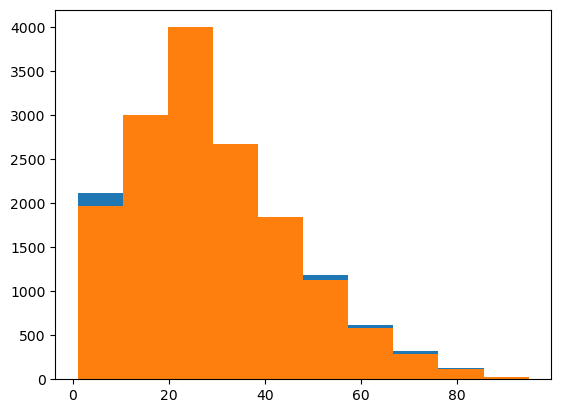

In [15]:
# Hard coral - out of 200 points
HC = np.round(xdata.HC.values)+1
nobs = len(HC)
plt.hist(HC)

# Lag-1 hard coral
HC1 = np.round(xdata.HC_1.values)+1
plt.hist(HC1)

# log lag-1 hard coral
lHC = np.log(HC)
lHC1 = np.log(HC1)

# Number of observations
nobs = len(lHC1)

In [16]:
def clean_and_log(arr):
    arr = arr.astype(float).copy()

    # Remplacer -999 par la moyenne (ou NaN selon ton choix)
    arr[arr == -999] = np.mean(arr[arr != -999])

    return stdize(np.log(arr + 1))


# Disturbance
Dist_ = xdata.DISTURBANCE.values.copy()
Dist_[Dist_ == '-999'] = 'U'
UNK = (Dist_ == 'U') * 1


# CoTS
CoTS = clean_and_log(xdata.C.values)

# Storm
STORM = clean_and_log(xdata.S.values)

# Bleaching
BLEACH = clean_and_log(xdata.B.values)

# Disease
DISEASE = clean_and_log(xdata.D.values)

# Herbivory (déjà OK mais harmonisé)
HERB = clean_and_log(xdata.HERB.values)

In [17]:
# Index each reef to a given cluster
Cluster, Ic = subindexall(xdata.CLUSTER.values, xdata.REEF_NAME.values)
ncluster = len(Cluster)

# Index each transect to a given reef
Reef,Ir = indexall(xdata.REEF_NAME.values)
nreefs = len(Reef)

# Index each transect to a given cluster
Cluster_t, Ict = indexall(xdata.CLUSTER.values)
nct = len(Cluster_t)

In [18]:
year = xdata.REPORT_YEAR.values
nyears = len(np.unique(year))
YR = xdata.REPORT_YEAR.values - 1995
maxyr = max(YR)

In [19]:
DIST = ['CoTS','Cyclones','Bleaching','Disease','Unknown']

In [20]:
# Index constant reef-scale covariates
rindx = np.array([list(xdata.REEF_NAME.values).index(x) for x in Reef])

# Get water quality values
WQ = xdata.PFsum.values[rindx]
# Mean water quality per cluster
Mean_wq = np.array([np.mean(WQ[Ic == i]) for i in range(ncluster)])
# Zero-centred water quality per cluster
ZcWQ = WQ - Mean_wq[Ic]

# Get zoning for resistance
ZONE = (xdata.iZONE.values + xdata.sZONE.values>0)*1
# Get zoning values for recovery
rZONE = ZONE[rindx]

# Get shelf position for each reef
Shelf,Is = indexall(xdata.SHELF.values)
nshelf = len(Shelf)

In [24]:
Model = pm.Model()

# Gompertz-based dynamics model
Model = pm.Model()

# Gompertz-based dynamics model
with Model:
    # Cluster-specific rate of increase
    r_Cluster = pm.Normal('r_Cluster', mu=1.2, sigma=100, shape=ncluster)
    # Cluster-specific density dependene
    a_Cluster = pm.Normal('a_Cluster', mu=0.3, sigma=100, shape=ncluster)
    
    # Within-cluster variation
    sigma_r = pm.Uniform('sigma_r', lower=0, upper=100, shape=ncluster)
    sigma_a = pm.Uniform('sigma_a', lower=0, upper=100, shape=ncluster)

    # Effect of zoning on recovery rate
    k0 = pm.Normal('Zone', mu=0.0, tau=0.001)
    # Effect of water quality on recovery rate
    e0 = pm.Normal('WQ', mu=0.0, tau=0.001)
    
    # Reef recovery rate model
    mu_r_reef = r_Cluster[Ic]+k0*rZONE+e0*WQ
    r_Reef = pm.Normal('r_Reef', mu=mu_r_reef, sigma=sigma_r[Ic], shape=nreefs)
    
    # Reef density-dependent parameter intercepts
    a_Reef = pm.Normal('a_Reef', mu=a_Cluster[Ic], sigma=sigma_a[Ic], shape=nreefs)
    
    # Direct disturbance effects on hard coral cover
    k2 = pm.Normal('CoTS', mu=0.0, sigma=100)
    s2 = pm.Uniform('SD_CoTS', lower=0.001, upper=100)
    g2 = pm.Normal('cots_', mu=k2, sigma=s2, shape=ncluster)
    k3 = pm.Normal('Storms', mu=0.0, sigma=100)
    s3 = pm.Uniform('SD_Storms', lower=0.001, upper=100)
    g3 = pm.Normal('Cyclones', mu=k3, sigma=s3, shape=nshelf)
    g4 = pm.Normal('Bleaching', mu=0.0, sigma=100)
    g5 = pm.Normal('Disease', mu=0.0, sigma=100)
    g6 = pm.Normal('Unknown', mu=0.0, sigma=100)
    
    # Effect of herbivory on recovery rate
    g7 = pm.Normal('Herbivory', mu=0.0, sigma=100)
    
    # Water quality interactions with disturbance
    g8 = pm.Normal('WQ_bleach', mu=0.0, sigma=100)
    g9 = pm.Normal('WQ_CoTS', mu=0.0, sigma=100)
    g10 = pm.Normal('WQ_Disease', mu=0.0, sigma=100)
    g11 = pm.Normal('WQ_Unknown', mu=0.0, sigma=100)
    
    # Zoning interactions with disturbance
    g12 = pm.Normal('Z_bleach', mu=0.0, sigma=100)
    g13 = pm.Normal('Z_CoTS', mu=0.0, sigma=100)
    g14 = pm.Normal('Z_Disease', mu=0.0, sigma=100)
    g15 = pm.Normal('Z_Unknown', mu=0.0, sigma=100)
    
    # Transect-level model
    mu = (r_Reef[Ir]+g7*HERB)+(1.-a_Reef[Ir])*lHC1+g2[Ict]*CoTS+g3[Is]*STORM+g4*BLEACH+g5*DISEASE+g6*UNK+g8*BLEACH*WQ[Ir]+g9*CoTS*WQ[Ir]+g10*DISEASE*WQ[Ir]+g11*UNK*WQ[Ir]+g12*BLEACH*ZONE+g13*CoTS*ZONE+g14*DISEASE*ZONE+g15*UNK*ZONE
    
    # Link function
    #logmu = tt.exp(mu)/100.
    
    # Likelihood
    #Yi = pm.Binomial('Yi', n=100, p=logmu, observed=HC)

    p = pm.math.sigmoid(mu)  # ensures 0 < p < 1
    Yi = pm.Binomial('Yi', n=100, p=p, observed=HC)


mu = (r_Reef[Ir] + g7*HERB) \
     + (1.-a_Reef[Ir])*lHC1 \
     + g2[Ict]*CoTS \
     + g3[Is]*STORM \
     + g4*BLEACH \
     + g5*DISEASE \
     + g6*UNK \
     + g8*BLEACH*WQ[Ir] \
     + g9*CoTS*WQ[Ir] \
     + g10*DISEASE*WQ[Ir] \
     + g11*UNK*WQ[Ir] \
     + g12*BLEACH*ZONE \
     + g13*CoTS*ZONE \
     + g14*DISEASE*ZONE \
     + g15*UNK*ZONE


In [25]:
# Sampling
with Model:
    # Draw samples using NUTS
    trace = pm.sample(1000, tune=1000, cores=2)

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [r_Cluster, a_Cluster, sigma_r, sigma_a, Zone, WQ, r_Reef, a_Reef, CoTS, SD_CoTS, cots_, Storms, SD_Storms, Cyclones, Bleaching, Disease, Unknown, Herbivory, WQ_bleach, WQ_CoTS, WQ_Disease, WQ_Unknown, Z_bleach, Z_CoTS, Z_Disease, Z_Unknown]


C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1105 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [45]:
summary_df = pm.stats.summary(trace)

In [49]:
summary_df.shape

(133, 9)

In [52]:
summary_df.head(10)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_Cluster[0],-4.482,0.367,-5.190,-3.825,0.008,0.008,2354.0,1626.0,1.0
r_Cluster[1],-4.709,0.170,-5.040,-4.393,0.004,0.004,2343.0,1791.0,1.0
r_Cluster[2],-4.552,0.195,-4.936,-4.192,0.005,0.005,1917.0,1394.0,1.0
r_Cluster[3],-4.156,0.130,-4.389,-3.907,0.003,0.003,2806.0,1584.0,1.0
a_Cluster[0],-0.133,0.097,-0.314,0.051,0.002,0.003,2103.0,1128.0,1.0
a_Cluster[1],-0.193,0.041,-0.279,-0.122,0.001,0.001,2148.0,1253.0,1.0
a_Cluster[2],-0.167,0.043,-0.254,-0.086,0.001,0.001,2365.0,1141.0,1.0
a_Cluster[3],0.045,0.040,-0.028,0.123,0.001,0.001,3031.0,1267.0,1.0
Zone,0.032,0.171,-0.273,0.370,0.003,0.003,2544.0,1814.0,1.0
WQ,-0.633,0.380,-1.397,0.066,0.007,0.008,3057.0,1555.0,1.0


In [51]:
summary_df.tail(40)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_Reef[37],-0.032,0.021,-0.068,0.009,0.000,0.000,3941.0,1696.0,1.00
a_Reef[38],-0.083,0.029,-0.136,-0.025,0.001,0.001,3155.0,1638.0,1.00
a_Reef[39],-0.332,0.028,-0.384,-0.278,0.000,0.001,3929.0,1506.0,1.00
a_Reef[40],0.039,0.042,-0.035,0.121,0.001,0.001,3192.0,1601.0,1.00
a_Reef[41],-0.298,0.024,-0.341,-0.254,0.000,0.001,4811.0,1449.0,1.00
a_Reef[42],-0.144,0.019,-0.180,-0.110,0.000,0.000,3902.0,1370.0,1.00
a_Reef[43],-0.203,0.021,-0.240,-0.162,0.000,0.001,4159.0,1447.0,1.00
a_Reef[44],-0.175,0.015,-0.203,-0.148,0.000,0.000,3386.0,1516.0,1.00
a_Reef[45],-0.126,0.014,-0.152,-0.100,0.000,0.000,3432.0,1532.0,1.00
CoTS,-0.166,0.157,-0.482,0.102,0.005,0.008,1391.0,1031.0,1.00


In [46]:
summary_df.to_csv("summary_trace.csv", index=True) 

In [43]:
# -----------------------------
# Années futures
# -----------------------------
years_future = np.arange(2018, 2023)  # 2018-2022
n_years = len(years_future)


# -----------------------------
# Clusters
# -----------------------------
Cluster_unique = np.array(xdata['CLUSTER'].unique())
ncluster = len(Cluster_unique)


# -----------------------------
# Récifs
# -----------------------------
Reefs = np.array(xdata['REEF_NAME'].unique())
nreefs = len(Reefs)

# Cluster associé à chaque récif
Ic_reef = np.array([
    xdata['CLUSTER'][xdata['REEF_NAME'] == r].iloc[0]
    for r in Reefs
])

cluster_to_index = {cl: i for i, cl in enumerate(Cluster_unique)}
Ic_reef_idx = np.array([cluster_to_index[c] for c in Ic_reef])


# -----------------------------
# HC par récif (année initiale)
# -----------------------------
HC_by_reef = np.array([
    np.mean(HC[Ir == r]) for r in range(nreefs)
])

HC_last = np.log(HC_by_reef + 1)


# -----------------------------
# Covariables par cluster
# -----------------------------
CoTS_by_cluster = np.array([
    np.mean(CoTS[Ict == i]) for i in range(ncluster)
])

BLEACH_by_cluster = np.array([
    np.mean(BLEACH[Ict == i]) for i in range(ncluster)
])

DISEASE_by_cluster = np.array([
    np.mean(DISEASE[Ict == i]) for i in range(ncluster)
])

UNK_by_cluster = np.array([
    np.mean(UNK[Ict == i]) for i in range(ncluster)
])

HERB_by_reef = np.array([
    np.mean(HERB[Ir == r]) for r in range(nreefs)
])


# -----------------------------
# Dimensions MCMC
# -----------------------------
n_chains = trace.posterior.dims['chain']
n_draws = trace.posterior.dims['draw']

n_samples = n_chains * n_draws


# -----------------------------
# Extraction des paramètres
# -----------------------------

# (chain, draw, reef) → (samples, reef)
r_Reef_all = trace.posterior['r_Reef'].values.reshape(n_samples, nreefs)
a_Reef_all = trace.posterior['a_Reef'].values.reshape(n_samples, nreefs)

# (chain, draw, cluster) → (samples, cluster)
cots_all = trace.posterior['cots_'].values.reshape(n_samples, ncluster)

# (chain, draw) → (samples,)
bleach_all = trace.posterior['Bleaching'].values.reshape(n_samples)
disease_all = trace.posterior['Disease'].values.reshape(n_samples)
unk_all = trace.posterior['Unknown'].values.reshape(n_samples)
herb_all = trace.posterior['Herbivory'].values.reshape(n_samples)


# -----------------------------
# Tableau de sortie
# -----------------------------
HC_future = np.zeros((n_samples, ncluster, n_years))


# -----------------------------
# Simulation
# -----------------------------
for t, year in enumerate(years_future):

    print(f"Prédictions pour {year}...")

    for i in range(n_samples):

        # Paramètres i
        r_Reef_i = r_Reef_all[i]
        a_Reef_i = a_Reef_all[i]

        g2_i = cots_all[i]
        g4_i = bleach_all[i]
        g5_i = disease_all[i]
        g6_i = unk_all[i]
        g7_i = herb_all[i]


        # Prédiction par cluster
        HC_pred_cluster = np.zeros(ncluster)

        for c in range(ncluster):

            idx_reef = Ic_reef_idx == c

            mu = (
                np.mean(r_Reef_i[idx_reef]
                        + g7_i * HERB_by_reef[idx_reef])
                + (1 - np.mean(a_Reef_i[idx_reef])) * HC_last[c]
                + g2_i[c] * CoTS_by_cluster[c]
                + g4_i * BLEACH_by_cluster[c]
                + g5_i * DISEASE_by_cluster[c]
                + g6_i * UNK_by_cluster[c]
            )

            # Logit → probabilité
            p = 1 / (1 + np.exp(-mu))

            # Simulation binomiale
            HC_pred_cluster[c] = np.random.binomial(n=100, p=p)


        HC_future[i, :, t] = HC_pred_cluster


    # Mise à jour HC pour année suivante
    HC_last = np.log(HC_future[:, :, t].mean(axis=0) + 1)


# -----------------------------
# DataFrame pour plotting
# -----------------------------
data_plot = []

HC_median = np.median(HC_future, axis=0)

for t, year in enumerate(years_future):

    for c, cl in enumerate(Cluster_unique):

        data_plot.append({
            'REPORT_YEAR': year,
            'HC': HC_median[c, t],
            'CLUSTER': cl
        })


df_plot = pd.DataFrame(data_plot)

C:\Users\lenov\AppData\Local\Temp\ipykernel_13780\1206513580.py:68: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = trace.posterior.dims['chain']
C:\Users\lenov\AppData\Local\Temp\ipykernel_13780\1206513580.py:69: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = trace.posterior.dims['draw']


Prédictions pour 2018...
Prédictions pour 2019...
Prédictions pour 2020...
Prédictions pour 2021...
Prédictions pour 2022...


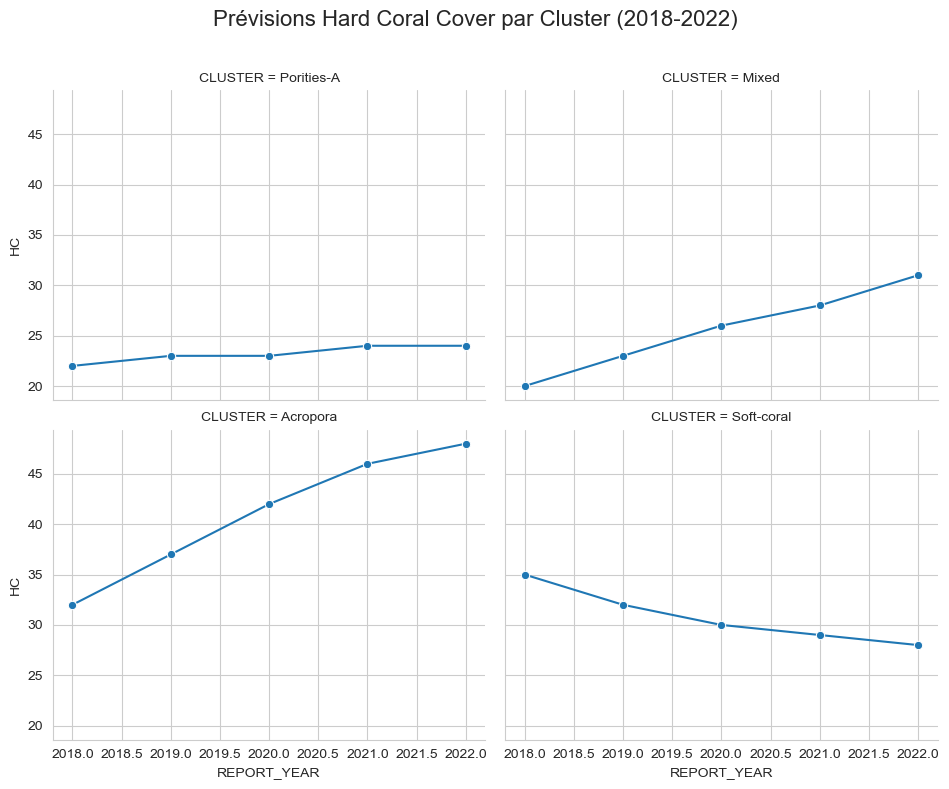

In [44]:
# -----------------------------
# Visualisation
# -----------------------------
g = sns.relplot(
    data=df_plot,
    x='REPORT_YEAR',
    y='HC',
    col='CLUSTER',
    kind='line',
    col_wrap=2,
    height=4,
    aspect=1.2,
    marker='o'
)

g.fig.suptitle(
    "Prévisions Hard Coral Cover par Cluster (2018-2022)",
    fontsize=16
)

g.fig.subplots_adjust(top=0.88)

plt.show()


In [41]:
HC_future = np.zeros((n_samples, nreefs, n_years))  
HC_last = np.log(HC_by_reef + 1)  

for t, year in enumerate(years_future):

    print(f"Prédictions pour {year}...")

    for i in range(n_samples):

        r_Reef_i = r_Reef_all[i]
        a_Reef_i = a_Reef_all[i]

        g2_i = cots_all[i]
        g4_i = bleach_all[i]
        g5_i = disease_all[i]
        g6_i = unk_all[i]
        g7_i = herb_all[i]

        # Prédiction par récif
        HC_pred_reef = np.zeros(nreefs)

        for r in range(nreefs):

            # Cluster associé au récif
            c = Ic_reef_idx[r]

            mu = (
                r_Reef_i[r] + g7_i * HERB_by_reef[r]
                + (1 - a_Reef_i[r]) * HC_last[r]
                + g2_i[c] * CoTS_by_cluster[c]
                + g4_i * BLEACH_by_cluster[c]
                + g5_i * DISEASE_by_cluster[c]
                + g6_i * UNK_by_cluster[c]
            )

            # Logit → probabilité
            p = 1 / (1 + np.exp(-mu))

            # Simulation binomiale
            HC_pred_reef[r] = np.random.binomial(n=100, p=p)

        HC_future[i, :, t] = HC_pred_reef

    # Mise à jour HC pour l'année suivante
    HC_last = np.log(HC_future[:, :, t].mean(axis=0) + 1)


data_plot = []
HC_median = np.median(HC_future, axis=0)  # shape : nreefs × n_years

for t, year in enumerate(years_future):
    for r, reef in enumerate(Reefs):
        data_plot.append({
            'REPORT_YEAR': year,
            'HC': HC_median[r, t],
            'REEF_NAME': reef
        })

df_plot = pd.DataFrame(data_plot)


Prédictions pour 2018...
Prédictions pour 2019...
Prédictions pour 2020...
Prédictions pour 2021...
Prédictions pour 2022...


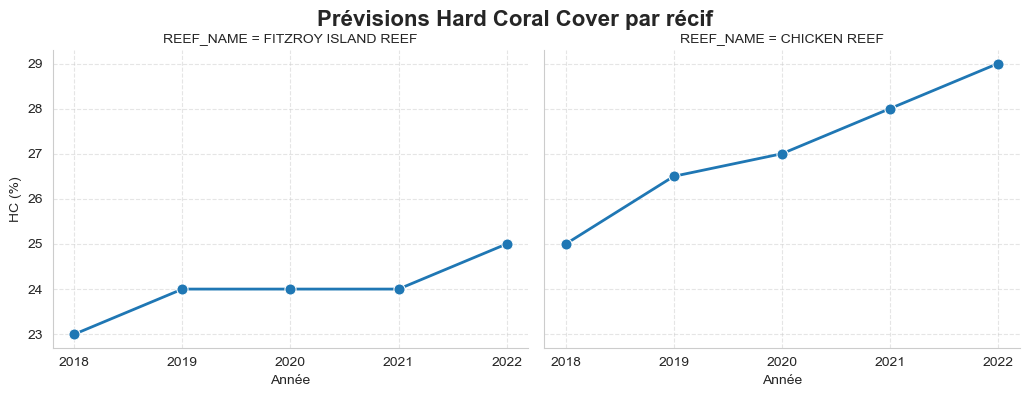

In [42]:
reefs_to_plot = ["FITZROY ISLAND REEF", "CHICKEN REEF"]
df_plot_selected = df_plot[df_plot['REEF_NAME'].isin(reefs_to_plot)]


sns.set_style("whitegrid")

g = sns.relplot(
    data=df_plot_selected,
    x='REPORT_YEAR',
    y='HC',
    col='REEF_NAME',
    kind='line',
    col_wrap=2,
    height=4,
    aspect=1.3,
    marker='o',
    markersize=8,
    linewidth=2
)

# Axe x : afficher uniquement les années
for ax in g.axes.flat:
    ax.set_xticks(years_future)
    ax.set_xticklabels([str(y) for y in years_future], rotation=0)
    ax.set_ylabel("HC (%)")
    ax.set_xlabel("Année")
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Titre général
g.fig.suptitle("Prévisions Hard Coral Cover par récif", fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.88)

plt.show()